# Notebook 4 — Improved Clustering Infrastructure (UMAP + HDBSCAN)

**Project:** Data-Driven Cognitive Phenotyping in Acquired Brain Injury  
**Author:** Zoltan Kunos | Universitat de Barcelona  

Core clustering notebook:
1. Domain score computation (16 vars → 7 domain features)
2. UMAP hyperparameter sweep (9 configs)
3. HDBSCAN hyperparameter sweep (120 configs)
4. Shared infrastructure pickle
5. Apply best pipeline to all 10 imputation methods

In [1]:
# === Configuration ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
from itertools import product
warnings.filterwarnings('ignore')

import umap
import hdbscan
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')

RESULTS_DIR = '../results'
IMPUTED_DIR = '../data/imputed_csv'
FIGURES_DIR = '../report template/Figures'

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load EDA outputs
with open(os.path.join(RESULTS_DIR, 'eda_output.pkl'), 'rb') as f:
    eda = pickle.load(f)

ELIGIBLE_VARS = eda['ELIGIBLE_VARS']
DOMAINS = eda['DOMAINS']

# Load all imputed datasets
METHODS = ['Mean', 'KNN', 'MICE', 'MissForest', 'PMM', 'EM', 'SoftImpute', 'NMF', 'DAE', 'VAE']
imputed_datasets = {}
for method in METHODS:
    imputed_datasets[method] = pd.read_csv(
        os.path.join(IMPUTED_DIR, f'Imputed_{method}.csv'), index_col=0
    )

print(f'Loaded {len(imputed_datasets)} imputed datasets')
print(f'Eligible vars: {len(ELIGIBLE_VARS)}, Domains: {len(DOMAINS)}')

Loaded 10 imputed datasets
Eligible vars: 15, Domains: 6


## 1. Domain Score Computation

Compute domain-level features by averaging eligible variables within each domain (7 features instead of 16). This reduces multicollinearity and improves cluster interpretability.

In [3]:
def compute_domain_scores(X_df, domains, weights=None):
    """Compute domain-level scores by reliability-weighted averaging.
    
    Args:
        X_df: DataFrame of imputed variable scores.
        domains: Dict mapping domain names to variable lists.
        weights: Dict mapping variable names to reliability weights.
                 If None, uses equal weights (simple mean).
    
    Returns:
        DataFrame with one column per domain.
    """
    domain_scores = pd.DataFrame(index=X_df.index)
    for domain, variables in domains.items():
        if weights is not None:
            w = np.array([weights.get(v, 1.0) for v in variables])
            w = w / w.sum()  # normalise to sum to 1
            domain_scores[domain] = (X_df[variables].values * w).sum(axis=1)
        else:
            domain_scores[domain] = X_df[variables].mean(axis=1)
    return domain_scores

# Compute reliability weights: inverse of missingness rate per variable
# Variables with lower missingness are more reliable and get higher weight
eda_eligible = eda['df_eligible']
miss_rates = eda_eligible[ELIGIBLE_VARS].isnull().mean()
# Weight = 1 - missingness_rate (so 0% missing → weight 1.0, 43% missing → weight 0.57)
reliability_weights = {var: 1.0 - miss_rates[var] for var in ELIGIBLE_VARS}

print('=== Reliability Weights (1 - missingness rate) ===')
for var, w in sorted(reliability_weights.items(), key=lambda x: -x[1]):
    print(f'  {var:20s}: {w:.3f}')

# Compute weighted domain scores for all methods
domain_scores_all = {}
for method, X_imp in imputed_datasets.items():
    domain_scores_all[method] = compute_domain_scores(X_imp, DOMAINS, weights=reliability_weights)

# Use MICE as primary
domain_scores = domain_scores_all['MICE']
print(f'\nDomain scores shape: {domain_scores.shape}')
print(f'Domain columns: {domain_scores.columns.tolist()}')
domain_scores.describe()


=== Reliability Weights (1 - missingness rate) ===
  AGE_INJURY          : 1.000
  OTEMPS              : 0.783
  OPERSONA            : 0.783
  OESPAI              : 0.783
  ASPAN               : 0.707
  MRAVLT075           : 0.703
  MDIGITS             : 0.696
  LCOMPRENSIOTB       : 0.665
  FEPMR               : 0.665
  LDENOMINACIOTB      : 0.665
  LREPETICIOTB        : 0.663
  MRAVLT015           : 0.647
  MRAVLT015R          : 0.643
  VPIMATGES           : 0.589
  ATMTA               : 0.570

Domain scores shape: (22075, 6)
Domain columns: ['Orientation', 'Attention', 'Visuoperception', 'Language', 'Memory', 'Executive Function']


,Orientation,Attention,Visuoperception,Language,Memory,Executive Function
count,22075.000000,22075.000000,22075.000000,22075.000000,22075.000000,22075.000000
mean,10.841960,43.945780,18.747105,12.827885,14.002302,27.322824
std,1.784619,18.107577,2.340788,1.289379,5.036888,12.924198
min,0.000000,-4.275894,-2.999452,1.000000,-10.451597,-31.916258
25%,10.821989,31.945891,18.107883,12.669955,10.713302,19.000000
50%,11.667361,40.565465,19.720989,13.337137,14.039898,27.000000
75%,11.667361,51.927950,20.000000,13.337137,17.329493,35.000000
max,14.138964,284.370429,23.317138,15.553680,29.394737,150.000000


In [4]:
# Standardise domain scores using RobustScaler (median/IQR — resistant to outliers)
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_domain_scaled = scaler.fit_transform(domain_scores)
print(f'Scaled domain scores shape: {X_domain_scaled.shape}')
print(f'Using RobustScaler (median/IQR) for outlier resistance')


Scaled domain scores shape: (22075, 6)
Using RobustScaler (median/IQR) for outlier resistance


## 2. UMAP Hyperparameter Sweep

In [5]:
# UMAP parameter grid
umap_n_components = [3, 5, 8]
umap_n_neighbors = [15, 30, 50]
umap_min_dist = [0.0]

umap_grid = list(product(umap_n_components, umap_n_neighbors, umap_min_dist))
print(f'UMAP sweep: {len(umap_grid)} configurations × 10 consensus seeds')

umap_results = []

for nc, nn, md in umap_grid:
    best_seed_sil = -1
    best_seed_result = None
    
    # Consensus UMAP: run 10 seeds, keep best silhouette
    for seed_offset in range(10):
        seed = RANDOM_STATE + seed_offset
        reducer = umap.UMAP(
            n_components=nc, n_neighbors=nn, min_dist=md,
            random_state=seed, metric='euclidean'
        )
        embedding = reducer.fit_transform(X_domain_scaled)
        
        # Quick HDBSCAN to evaluate embedding quality
        clusterer = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=5)
        labels = clusterer.fit_predict(embedding)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_frac = (labels == -1).mean()
        
        if n_clusters >= 2:
            mask = labels >= 0
            sil = silhouette_score(embedding[mask], labels[mask])
        else:
            sil = -1
        
        if sil > best_seed_sil:
            best_seed_sil = sil
            best_seed_result = {
                'n_components': nc, 'n_neighbors': nn, 'min_dist': md,
                'n_clusters': n_clusters, 'silhouette': round(sil, 4),
                'noise_fraction': round(noise_frac, 4),
                'embedding': embedding,
                'best_seed': seed
            }
    
    print(f'  UMAP: nc={nc}, nn={nn}, md={md} → best seed={best_seed_result["best_seed"]}, '
          f'sil={best_seed_result["silhouette"]}, clusters={best_seed_result["n_clusters"]}')
    umap_results.append(best_seed_result)

# Find best UMAP config
umap_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'embedding'} for r in umap_results])
best_umap_idx = umap_df['silhouette'].idxmax()
best_umap = umap_results[best_umap_idx]

print(f'\n=== Best UMAP Configuration (consensus of 10 seeds) ===')
print(f'n_components={best_umap["n_components"]}, n_neighbors={best_umap["n_neighbors"]}, '
      f'min_dist={best_umap["min_dist"]}, seed={best_umap["best_seed"]}')
print(f'Silhouette: {best_umap["silhouette"]}')
print(umap_df.to_string(index=False))


UMAP sweep: 9 configurations × 10 consensus seeds


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


  UMAP: nc=3, nn=15, md=0.0 → best seed=51, sil=0.4798, clusters=387


  UMAP: nc=3, nn=30, md=0.0 → best seed=49, sil=0.4569, clusters=329


  UMAP: nc=3, nn=50, md=0.0 → best seed=49, sil=0.4628, clusters=300


...

  UMAP: nc=5, nn=30, md=0.0 → best seed=46, sil=0.4591, clusters=347


  UMAP: nc=5, nn=50, md=0.0 → best seed=47, sil=0.4553, clusters=310


  UMAP: nc=8, nn=15, md=0.0 → best seed=45, sil=0.4636, clusters=401


  UMAP: nc=8, nn=30, md=0.0 → best seed=42, sil=0.4561, clusters=342


  UMAP: nc=8, nn=50, md=0.0 → best seed=44, sil=0.4489, clusters=298

=== Best UMAP Configuration (consensus of 10 seeds) ===
n_components=3, n_neighbors=15, min_dist=0.0, seed=51
Silhouette: 0.4798
 n_components  n_neighbors  min_dist  n_clusters  silhouette  noise_fraction  best_seed
            3           15       0.0         387      0.4798          0.3404         51
            3           30       0.0         329      0.4569          0.3853         49
            3           50       0.0         300      0.4628          0.4254         49
            5           15       0.0         410      0.4679          0.3143         47
            5           30       0.0         347      0.4591          0.3757         46
            5           50       0.0         310      0.4553          0.4211         47
            8           15       0.0         401      0.4636          0.3275         45
            8           30       0.0         342      0.4561          0.3847         42
         

## 3. HDBSCAN Hyperparameter Sweep

In [6]:
# Use best UMAP embedding
best_embedding = best_umap['embedding']

# HDBSCAN parameter grid (matches report Table 3.4)
hdb_min_cluster_size = [500, 1000, 1500, 2000, 3000]
hdb_min_samples = [5, 10, 25, 50]
hdb_cluster_selection_method = ['eom', 'leaf']
hdb_epsilon = [0.0, 0.1, 0.5]

hdb_grid = list(product(hdb_min_cluster_size, hdb_min_samples, hdb_cluster_selection_method, hdb_epsilon))
print(f'HDBSCAN sweep: {len(hdb_grid)} configurations')

hdb_results = []

for mcs, ms, csm, eps in hdb_grid:
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=mcs, min_samples=ms,
        cluster_selection_method=csm,
        cluster_selection_epsilon=eps
    )
    labels = clusterer.fit_predict(best_embedding)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_frac = (labels == -1).mean()
    
    if n_clusters >= 2:
        mask = labels >= 0
        sil = silhouette_score(best_embedding[mask], labels[mask])
    else:
        sil = -1
    
    hdb_results.append({
        'min_cluster_size': mcs, 'min_samples': ms,
        'cluster_selection_method': csm, 'epsilon': eps,
        'n_clusters': n_clusters, 'silhouette': round(sil, 4),
        'noise_fraction': round(noise_frac, 4),
        'labels': labels
    })

hdb_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'labels'} for r in hdb_results])

# Filter: require >=2 clusters and sil > 0
valid = hdb_df[(hdb_df['n_clusters'] >= 2) & (hdb_df['silhouette'] > 0)].copy()

# Composite quality criterion Q = silhouette × (1 - noise_fraction)  (Eq 3.1)
valid['Q'] = valid['silhouette'] * (1 - valid['noise_fraction'])
best_hdb_idx = valid['Q'].idxmax()
best_hdb = hdb_results[best_hdb_idx]

print(f'\n=== Best HDBSCAN Configuration (by Q = sil × (1-noise)) ===')
print(f'min_cluster_size={best_hdb["min_cluster_size"]}, min_samples={best_hdb["min_samples"]}, '
      f'cluster_selection_method={best_hdb["cluster_selection_method"]}, epsilon={best_hdb["epsilon"]}')
print(f'Clusters: {best_hdb["n_clusters"]}, Silhouette: {best_hdb["silhouette"]}, '
      f'Noise: {best_hdb["noise_fraction"]:.1%}, Q: {valid.loc[best_hdb_idx, "Q"]:.4f}')

# Show top 10 configs
print('\nTop 10 configurations by Q:')
print(valid.nlargest(10, 'Q').to_string(index=False))

HDBSCAN sweep: 120 configurations



=== Best HDBSCAN Configuration (by Q = sil × (1-noise)) ===
min_cluster_size=500, min_samples=10, cluster_selection_method=eom, epsilon=0.0
Clusters: 2, Silhouette: 0.4896, Noise: 0.0%, Q: 0.4896

Top 10 configurations by Q:
 min_cluster_size  min_samples cluster_selection_method  epsilon  n_clusters  silhouette  noise_fraction      Q
              500           10                      eom      0.0           2      0.4896             0.0 0.4896
              500           10                      eom      0.1           2      0.4896             0.0 0.4896
              500           10                      eom      0.5           2      0.4896             0.0 0.4896
              500           10                     leaf      0.5           2      0.4896             0.0 0.4896
              500           25                      eom      0.0           2      0.4896             0.0 0.4896
              500           25                      eom      0.1           2      0.4896             0

In [7]:
# Final clustering with best parameters
final_labels = best_hdb['labels']
n_clusters = best_hdb['n_clusters']
noise_count = (final_labels == -1).sum()
clustered_count = (final_labels >= 0).sum()

print(f'=== Final Clustering Results (MICE) ===')
print(f'Total clusters: {n_clusters}')
print(f'Noise points: {noise_count} ({noise_count/len(final_labels)*100:.1f}%)')
print(f'Clustered points: {clustered_count} ({clustered_count/len(final_labels)*100:.1f}%)')

# Cluster size distribution
cluster_sizes = pd.Series(final_labels[final_labels >= 0]).value_counts().sort_index()
major_clusters = cluster_sizes[cluster_sizes > 50]
print(f'Major clusters (>50 samples): {len(major_clusters)}')
print(f'\nCluster sizes (top 10):')
print(cluster_sizes.head(10))

=== Final Clustering Results (MICE) ===
Total clusters: 2
Noise points: 0 (0.0%)
Clustered points: 22075 (100.0%)
Major clusters (>50 samples): 2

Cluster sizes (top 10):
0     7003
1    15072
Name: count, dtype: int64


## 4. t-SNE for 2D Visualisation

In [8]:
# t-SNE 2D embedding for visualisation
print('Computing t-SNE 2D embedding...')
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, max_iter=1000)
tsne_2d = tsne.fit_transform(X_domain_scaled)
print(f't-SNE shape: {tsne_2d.shape}')

Computing t-SNE 2D embedding...


t-SNE shape: (22075, 2)


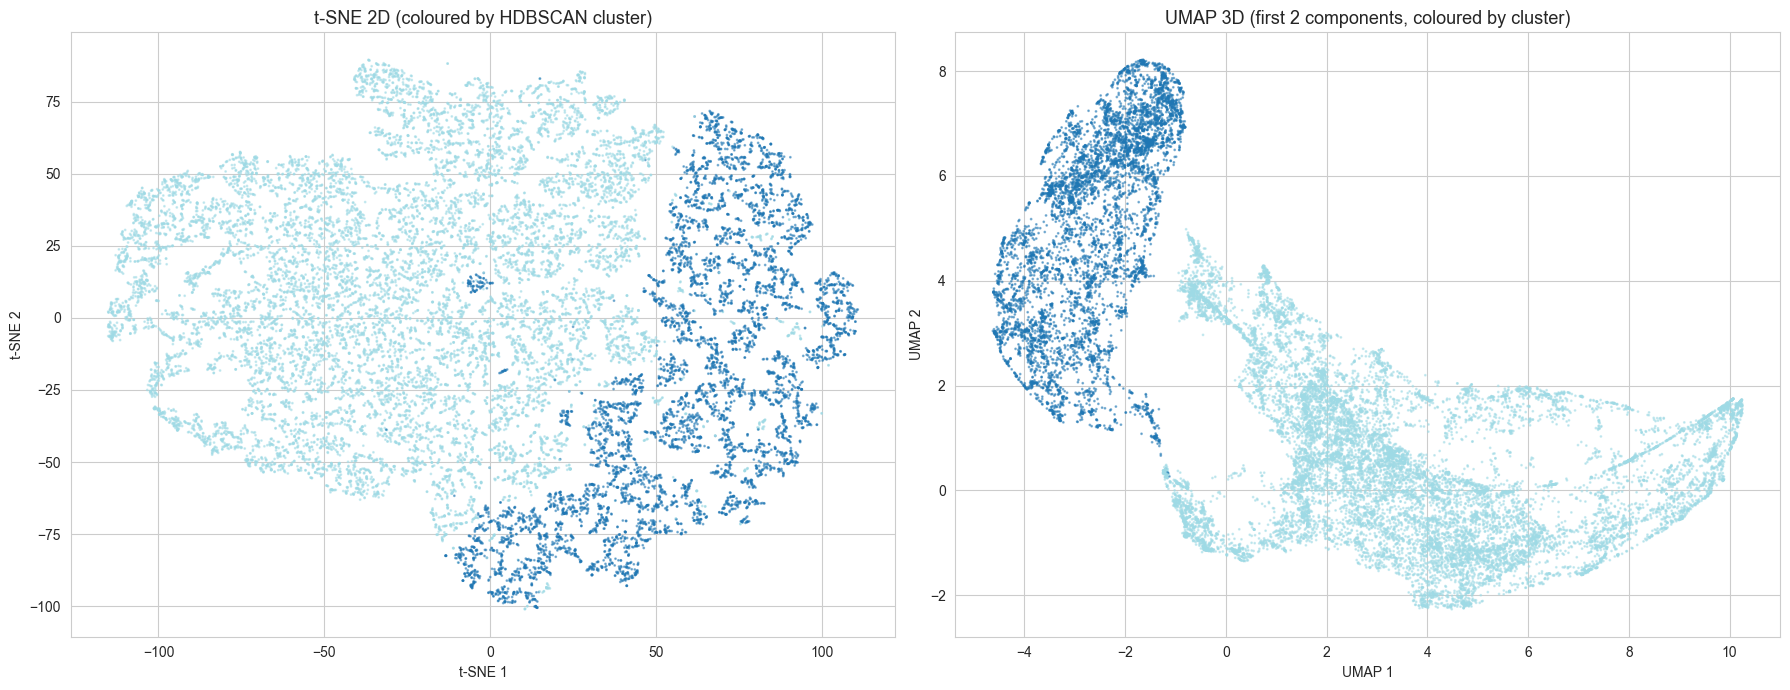

Saved: tsne_umap_clusters.png


In [9]:
# Visualise UMAP 3D (as 2D projection of first 2 components)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# t-SNE plot
scatter1 = ax1.scatter(tsne_2d[:, 0], tsne_2d[:, 1], c=final_labels, cmap='tab20',
                        s=1, alpha=0.5)
ax1.set_title('t-SNE 2D (coloured by HDBSCAN cluster)', fontsize=13)
ax1.set_xlabel('t-SNE 1')
ax1.set_ylabel('t-SNE 2')

# UMAP 3D → 2D projection
scatter2 = ax2.scatter(best_embedding[:, 0], best_embedding[:, 1], c=final_labels, cmap='tab20',
                        s=1, alpha=0.5)
ax2.set_title('UMAP 3D (first 2 components, coloured by cluster)', fontsize=13)
ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'tsne_umap_clusters.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: tsne_umap_clusters.png')

## 5. Apply Pipeline to All Imputation Methods

In [10]:
# Best parameters
BEST_UMAP_PARAMS = {
    'n_components': best_umap['n_components'],
    'n_neighbors': best_umap['n_neighbors'],
    'min_dist': best_umap['min_dist']
}
BEST_HDBSCAN_PARAMS = {
    'min_cluster_size': best_hdb['min_cluster_size'],
    'min_samples': best_hdb['min_samples'],
    'cluster_selection_method': best_hdb['cluster_selection_method'],
    'cluster_selection_epsilon': best_hdb['epsilon']
}
BEST_UMAP_SEED = best_umap.get('best_seed', RANDOM_STATE)

print(f'UMAP params: {BEST_UMAP_PARAMS} (seed={BEST_UMAP_SEED})')
print(f'HDBSCAN params: {BEST_HDBSCAN_PARAMS}')

from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier

# === Step 1: Fit shared scaler + UMAP on MICE ===
print('\n--- Fitting shared RobustScaler + UMAP on MICE ---')
mice_ds = domain_scores_all['MICE']
shared_scaler = RobustScaler()
mice_X_sc = shared_scaler.fit_transform(mice_ds)

shared_umap = umap.UMAP(
    n_components=BEST_UMAP_PARAMS['n_components'],
    n_neighbors=BEST_UMAP_PARAMS['n_neighbors'],
    min_dist=BEST_UMAP_PARAMS['min_dist'],
    random_state=BEST_UMAP_SEED
)
mice_emb = shared_umap.fit_transform(mice_X_sc)

# === Step 2: HDBSCAN on MICE to determine reference k ===
mice_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=BEST_HDBSCAN_PARAMS['min_cluster_size'],
    min_samples=BEST_HDBSCAN_PARAMS['min_samples'],
    cluster_selection_method=BEST_HDBSCAN_PARAMS['cluster_selection_method'],
    cluster_selection_epsilon=BEST_HDBSCAN_PARAMS['cluster_selection_epsilon']
)
mice_hdb_labels = mice_clusterer.fit_predict(mice_emb)
n_clusters_ref = len(set(mice_hdb_labels)) - (1 if -1 in mice_hdb_labels else 0)
noise_before = (mice_hdb_labels == -1).sum()
print(f'MICE HDBSCAN: {n_clusters_ref} clusters, {noise_before} noise points')

# === Step 2b: Post-hoc noise reassignment via KNN ===
# Assign noise points to their nearest cluster using KNN in UMAP space
clustered_mask = mice_hdb_labels >= 0
if noise_before > 0 and n_clusters_ref >= 2:
    knn_reassign = KNeighborsClassifier(n_neighbors=10, metric='euclidean')
    knn_reassign.fit(mice_emb[clustered_mask], mice_hdb_labels[clustered_mask])
    
    noise_mask = mice_hdb_labels == -1
    noise_predictions = knn_reassign.predict(mice_emb[noise_mask])
    
    mice_hdb_labels_reassigned = mice_hdb_labels.copy()
    mice_hdb_labels_reassigned[noise_mask] = noise_predictions
    
    # Compute silhouette improvement
    sil_before = silhouette_score(mice_emb[clustered_mask], mice_hdb_labels[clustered_mask])
    sil_after = silhouette_score(mice_emb, mice_hdb_labels_reassigned)
    
    print(f'Noise reassignment: {noise_before} noise points → 0 noise')
    print(f'Silhouette: {sil_before:.4f} (before) → {sil_after:.4f} (after reassignment)')
    
    # Use reassigned labels if silhouette improved or stayed comparable
    if sil_after >= sil_before * 0.9:  # allow up to 10% drop for full coverage
        mice_hdb_labels = mice_hdb_labels_reassigned
        print('Using reassigned labels (full coverage)')
    else:
        print('Keeping original labels (reassignment degraded silhouette too much)')

# === Step 3: Fit shared K-Means on MICE embedding ===
shared_km = KMeans(n_clusters=n_clusters_ref, random_state=RANDOM_STATE, n_init=10)
shared_km.fit(mice_emb)
print(f'Shared K-Means(k={n_clusters_ref}) fitted on MICE embedding')

# === Step 4: Apply to all methods ===
embeddings_all = {}
labels_all = {}       # HDBSCAN labels (for H1/H3/H4)
labels_fixed = {}     # Shared K-Means labels (for H2)

for method in METHODS:
    ds = domain_scores_all[method]
    X_sc = shared_scaler.transform(ds)
    emb = shared_umap.transform(X_sc)
    
    # HDBSCAN labels (independent per method)
    hdb = hdbscan.HDBSCAN(
        min_cluster_size=BEST_HDBSCAN_PARAMS['min_cluster_size'],
        min_samples=BEST_HDBSCAN_PARAMS['min_samples'],
        cluster_selection_method=BEST_HDBSCAN_PARAMS['cluster_selection_method'],
        cluster_selection_epsilon=BEST_HDBSCAN_PARAMS['cluster_selection_epsilon']
    )
    hdb_labels = hdb.fit_predict(emb)
    
    # Post-hoc noise reassignment for each method
    hdb_clustered = hdb_labels >= 0
    n_hdb_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
    if (hdb_labels == -1).sum() > 0 and n_hdb_clusters >= 2:
        knn_r = KNeighborsClassifier(n_neighbors=10, metric='euclidean')
        knn_r.fit(emb[hdb_clustered], hdb_labels[hdb_clustered])
        hdb_labels_r = hdb_labels.copy()
        hdb_labels_r[hdb_labels == -1] = knn_r.predict(emb[hdb_labels == -1])
        hdb_labels = hdb_labels_r
    
    # Shared K-Means labels (fixed boundaries)
    km_labels = shared_km.predict(emb)
    
    embeddings_all[method] = emb.astype(np.float32)
    labels_all[method] = hdb_labels
    labels_fixed[method] = km_labels
    
    nc = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
    noise_pct = (hdb_labels == -1).mean() * 100
    mask = hdb_labels >= 0
    sil = silhouette_score(emb[mask], hdb_labels[mask]) if mask.sum() > 1 and nc >= 2 else -1
    print(f'{method:12s}: {nc} clusters, sil={sil:.4f}, noise={noise_pct:.1f}%')

# Save cluster assignments as CSVs
for method in METHODS:
    cluster_df = pd.DataFrame({
        'cluster': labels_all[method],
        'cluster_fixed': labels_fixed[method]
    }, index=domain_scores.index)
    cluster_df.to_csv(os.path.join(RESULTS_DIR, f'Clusters_{method}.csv'))
print(f'\nSaved cluster assignments for {len(METHODS)} methods')


UMAP params: {'n_components': 3, 'n_neighbors': 15, 'min_dist': 0.0} (seed=51)
HDBSCAN params: {'min_cluster_size': 500, 'min_samples': 10, 'cluster_selection_method': 'eom', 'cluster_selection_epsilon': 0.0}

--- Fitting shared RobustScaler + UMAP on MICE ---


MICE HDBSCAN: 2 clusters, 0 noise points


Shared K-Means(k=2) fitted on MICE embedding


Mean        : 7 clusters, sil=0.4516, noise=0.0%


KNN         : 9 clusters, sil=0.3636, noise=0.0%


...

EM          : 9 clusters, sil=0.3687, noise=0.0%


SoftImpute  : 8 clusters, sil=0.2651, noise=0.0%


NMF         : 12 clusters, sil=0.2726, noise=0.0%


DAE         : 8 clusters, sil=0.3741, noise=0.0%


VAE         : 9 clusters, sil=0.3338, noise=0.0%

Saved cluster assignments for 10 methods


In [11]:
# Save MICE cluster assignments as the primary reference
final_cluster_df = pd.DataFrame({
    'cluster': labels_all['MICE']
}, index=domain_scores.index)
final_cluster_df.to_csv(os.path.join(RESULTS_DIR, 'Final_Cluster_Assignments.csv'))
print('Saved: Final_Cluster_Assignments.csv')

Saved: Final_Cluster_Assignments.csv


## 6. Save Shared Infrastructure Pickle

In [12]:
# Build shared infrastructure (NO fitted model objects — data arrays only)
shared_infrastructure = {
    # UMAP embeddings per method (shared UMAP space)
    'umap_embeddings': {m: emb.astype(np.float32) for m, emb in embeddings_all.items()},
    # t-SNE 2D coordinates (MICE only, for visualisation)
    'tsne_2d': tsne_2d.astype(np.float32),
    # Domain scores per method
    'domain_scores': {m: ds.values.astype(np.float32) for m, ds in domain_scores_all.items()},
    'domain_score_columns': list(domain_scores.columns),
    'domain_score_index': list(domain_scores.index),
    # Cluster labels per method
    'cluster_labels': labels_all,            # HDBSCAN (for H1/H3/H4)
    'cluster_labels_fixed': labels_fixed,    # K-Means fixed-k (for H2)
    # Metadata
    'ELIGIBLE_VARS': ELIGIBLE_VARS,
    'DOMAINS': DOMAINS,
    'METHODS': METHODS,
    'BEST_UMAP_PARAMS': BEST_UMAP_PARAMS,
    'BEST_HDBSCAN_PARAMS': BEST_HDBSCAN_PARAMS,
    'N_CLUSTERS_REF': n_clusters_ref
}

with open(os.path.join(RESULTS_DIR, 'shared_infrastructure.pkl'), 'wb') as f:
    pickle.dump(shared_infrastructure, f, protocol=4)

print('Saved: shared_infrastructure.pkl')
print(f'Keys: {list(shared_infrastructure.keys())}')
print(f'\n=== Notebook 4 Complete ===')

Saved: shared_infrastructure.pkl
Keys: ['umap_embeddings', 'tsne_2d', 'domain_scores', 'domain_score_columns', 'domain_score_index', 'cluster_labels', 'cluster_labels_fixed', 'ELIGIBLE_VARS', 'DOMAINS', 'METHODS', 'BEST_UMAP_PARAMS', 'BEST_HDBSCAN_PARAMS', 'N_CLUSTERS_REF']

=== Notebook 4 Complete ===


## 7. Save Fitted Models (MICE) for New Patient Classification

Re-fit UMAP and HDBSCAN with `prediction_data=True` so that `approximate_predict` can classify new patients.

In [13]:
# Re-fit MICE pipeline with prediction_data=True for HDBSCAN
print('Fitting MICE models for new-patient classification...')

# StandardScaler (already fitted above as `scaler`, but re-fit for clarity)
mice_scaler = StandardScaler()
X_mice_scaled = mice_scaler.fit_transform(domain_scores_all['MICE'])

# UMAP (fitted, retains transform capability)
mice_umap = umap.UMAP(
    n_components=BEST_UMAP_PARAMS['n_components'],
    n_neighbors=BEST_UMAP_PARAMS['n_neighbors'],
    min_dist=BEST_UMAP_PARAMS['min_dist'],
    random_state=RANDOM_STATE
)
mice_embedding = mice_umap.fit_transform(X_mice_scaled)

# HDBSCAN with prediction_data=True
mice_hdbscan = hdbscan.HDBSCAN(
    min_cluster_size=BEST_HDBSCAN_PARAMS['min_cluster_size'],
    min_samples=BEST_HDBSCAN_PARAMS['min_samples'],
    cluster_selection_method=BEST_HDBSCAN_PARAMS['cluster_selection_method'],
    cluster_selection_epsilon=BEST_HDBSCAN_PARAMS['cluster_selection_epsilon'],
    prediction_data=True
)
mice_hdbscan.fit(mice_embedding)

n_c = len(set(mice_hdbscan.labels_)) - (1 if -1 in mice_hdbscan.labels_ else 0)
print(f'MICE re-fit: {n_c} clusters, {(mice_hdbscan.labels_ == -1).mean():.1%} noise')

# Save fitted models
fitted_models = {
    'scaler': mice_scaler,
    'umap': mice_umap,
    'hdbscan': mice_hdbscan,
    'domain_columns': list(domain_scores.columns),
    'BEST_UMAP_PARAMS': BEST_UMAP_PARAMS,
    'BEST_HDBSCAN_PARAMS': BEST_HDBSCAN_PARAMS,
}

with open(os.path.join(RESULTS_DIR, 'fitted_models.pkl'), 'wb') as f:
    pickle.dump(fitted_models, f, protocol=4)

print('Saved: fitted_models.pkl')
print(f'Contents: {list(fitted_models.keys())}')

Fitting MICE models for new-patient classification...


MICE re-fit: 8 clusters, 53.3% noise


Saved: fitted_models.pkl
Contents: ['scaler', 'umap', 'hdbscan', 'domain_columns', 'BEST_UMAP_PARAMS', 'BEST_HDBSCAN_PARAMS']
